In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import networkx as nx
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


In [2]:
df_ADP = pd.read_csv("../../../../Thomson Lab Dropbox/David Larios/activedrops/paper/Jiapei/MD_motors/interaction energy/ADP_energy_final.csv")
df_APO = pd.read_csv("../../../../Thomson Lab Dropbox/David Larios/activedrops/paper/Jiapei/MD_motors/interaction energy/APO_energy_final.csv")
df_ATP = pd.read_csv("../../../../Thomson Lab Dropbox/David Larios/activedrops/paper/Jiapei/MD_motors/interaction energy/ATP_energy_final.csv")

# Calculate the mean value for all columns from 25 ns onwards for each dataframe and combine into a single DataFrame
mean_from_25ns_ADP = df_ADP[df_ADP[df_ADP.columns[0]] >= 25].mean()
mean_from_25ns_APO = df_APO[df_APO[df_APO.columns[0]] >= 25].mean()
mean_from_25ns_ATP = df_ATP[df_ATP[df_ATP.columns[0]] >= 25].mean()

mean_from_25ns_all = pd.DataFrame({
    'ADP': mean_from_25ns_ADP,
    'APO': mean_from_25ns_APO,
    'ATP': mean_from_25ns_ATP
})

# Omit the first row
energies = mean_from_25ns_all.iloc[1:]

energies


,ADP,APO,ATP
k401,-1758.962391,-1550.184006,-1552.809780
b,-1956.810849,-1769.097855,-1718.960722
c,-1578.762166,-1467.323488,-1937.242556
d,-2186.256168,-1284.005719,-1671.138662
e,-1680.047272,-1642.489441,-1544.317038
f,-2362.603404,-2087.105575,-1926.219253
g,-1438.985040,-1555.516315,-1614.333096
kif3,-1806.459957,-1838.572009,-1998.817542
acsu2,-1851.708912,-1662.519335,-1835.155743
adpa,-1882.006800,-1802.427027,-1811.677343


In [3]:
# First, let's examine the data structure
print("Data shape:", energies.shape)
print("\nFirst few rows:")
print(energies.head())
print("\nData types:")
print(energies.dtypes)
print("\nBasic statistics:")
print(energies.describe())


Data shape: (18, 3)

First few rows:
              ADP          APO          ATP
k401 -1758.962391 -1550.184006 -1552.809780
b    -1956.810849 -1769.097855 -1718.960722
c    -1578.762166 -1467.323488 -1937.242556
d    -2186.256168 -1284.005719 -1671.138662
e    -1680.047272 -1642.489441 -1544.317038

Data types:
ADP    float64
APO    float64
ATP    float64
dtype: object

Basic statistics:
               ADP          APO          ATP
count    18.000000    18.000000    18.000000
mean  -1876.214715 -1741.773625 -1823.772504
std     231.875126   219.525627   172.195847
min   -2362.603404 -2087.105575 -2154.898587
25%   -2025.797327 -1848.382283 -1934.486730
50%   -1866.857856 -1779.733546 -1852.381411
75%   -1769.456995 -1577.259597 -1683.094177
max   -1438.985040 -1284.005719 -1544.317038


In [4]:
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")


PCA Explained Variance Ratio:
PC1: 0.684 (68.4%)
PC2: 0.195 (19.5%)
PC3: 0.121 (12.1%)

Cumulative explained variance: [0.68362734 0.87863893 1.        ]
Total variance explained by first 3 PCs: 1.000


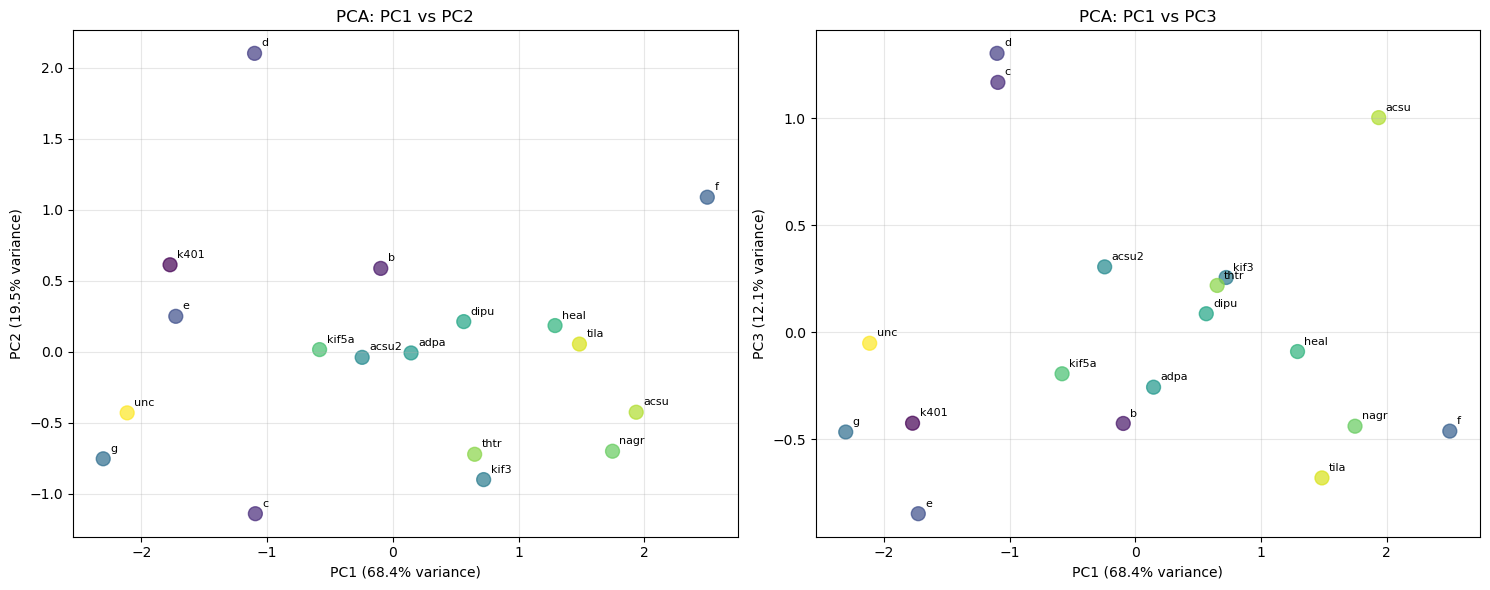

In [5]:
# 1. PRINCIPAL COMPONENT ANALYSIS (PCA)
# Standardize the data for PCA
scaler = StandardScaler()
energies_scaled = scaler.fit_transform(energies)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(energies_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'], index=energies.index)
pca_df['Motor'] = energies.index

print("PCA Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.3f} ({ratio*100:.1f}%)")

print(f"\nCumulative explained variance: {pca.explained_variance_ratio_.cumsum()[:3]}")
print(f"Total variance explained by first 3 PCs: {pca.explained_variance_ratio_.cumsum()[2]:.3f}")

# Plot PCA results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PC1 vs PC2
scatter = axes[0].scatter(pca_df['PC1'], pca_df['PC2'], c=range(len(pca_df)), cmap='viridis', s=100, alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA: PC1 vs PC2')
axes[0].grid(True, alpha=0.3)

# Add motor labels
for i, motor in enumerate(pca_df['Motor']):
    axes[0].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# PC1 vs PC3
scatter = axes[1].scatter(pca_df['PC1'], pca_df['PC3'], c=range(len(pca_df)), cmap='viridis', s=100, alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)')
axes[1].set_title('PCA: PC1 vs PC3')
axes[1].grid(True, alpha=0.3)

# Add motor labels
for i, motor in enumerate(pca_df['Motor']):
    axes[1].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC3'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()


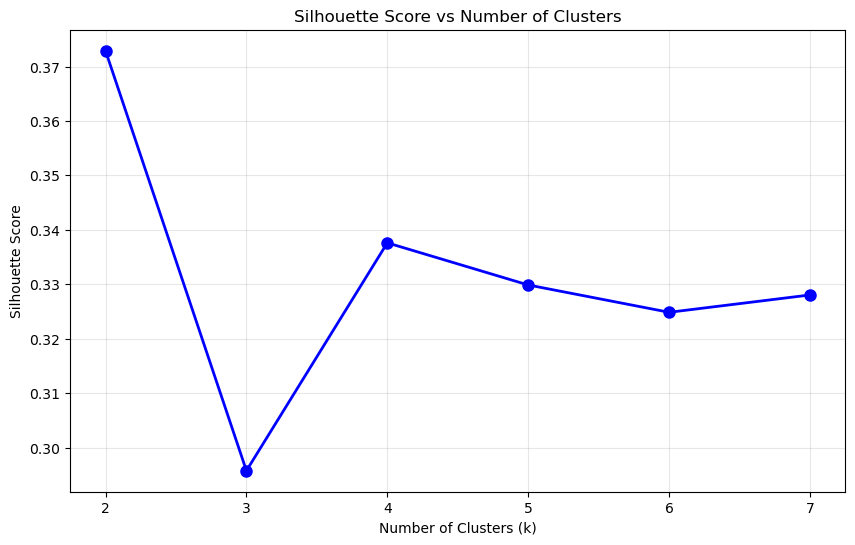

Optimal number of clusters based on silhouette score: 2
Silhouette scores: {2: 0.37290440729357194, 3: 0.29573717399134264, 4: 0.3376050434225749, 5: 0.3298642739426074, 6: 0.3248457493954744, 7: 0.3280308321588482}


In [6]:
# 2. CLUSTERING ANALYSIS
# Determine optimal number of clusters using silhouette score
silhouette_scores = []
K_range = range(2, min(8, len(energies)))  # Test 2 to 7 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(energies_scaled)
    silhouette_avg = silhouette_score(energies_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

# Find optimal number of clusters
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Silhouette scores: {dict(zip(K_range, silhouette_scores))}")


K-means Clustering Results:
Cluster 0: ['k401', 'b', 'c', 'd', 'e', 'g', 'acsu2', 'kif5a', 'unc']
Cluster 1: ['f', 'kif3', 'adpa', 'dipu', 'heal', 'nagr', 'thtr', 'acsu', 'tila']

Hierarchical Clustering Results:
Cluster 0: ['k401', 'b', 'c', 'd', 'e', 'g', 'acsu2', 'adpa', 'dipu', 'kif5a', 'unc']
Cluster 1: ['f', 'kif3', 'heal', 'nagr', 'thtr', 'acsu', 'tila']


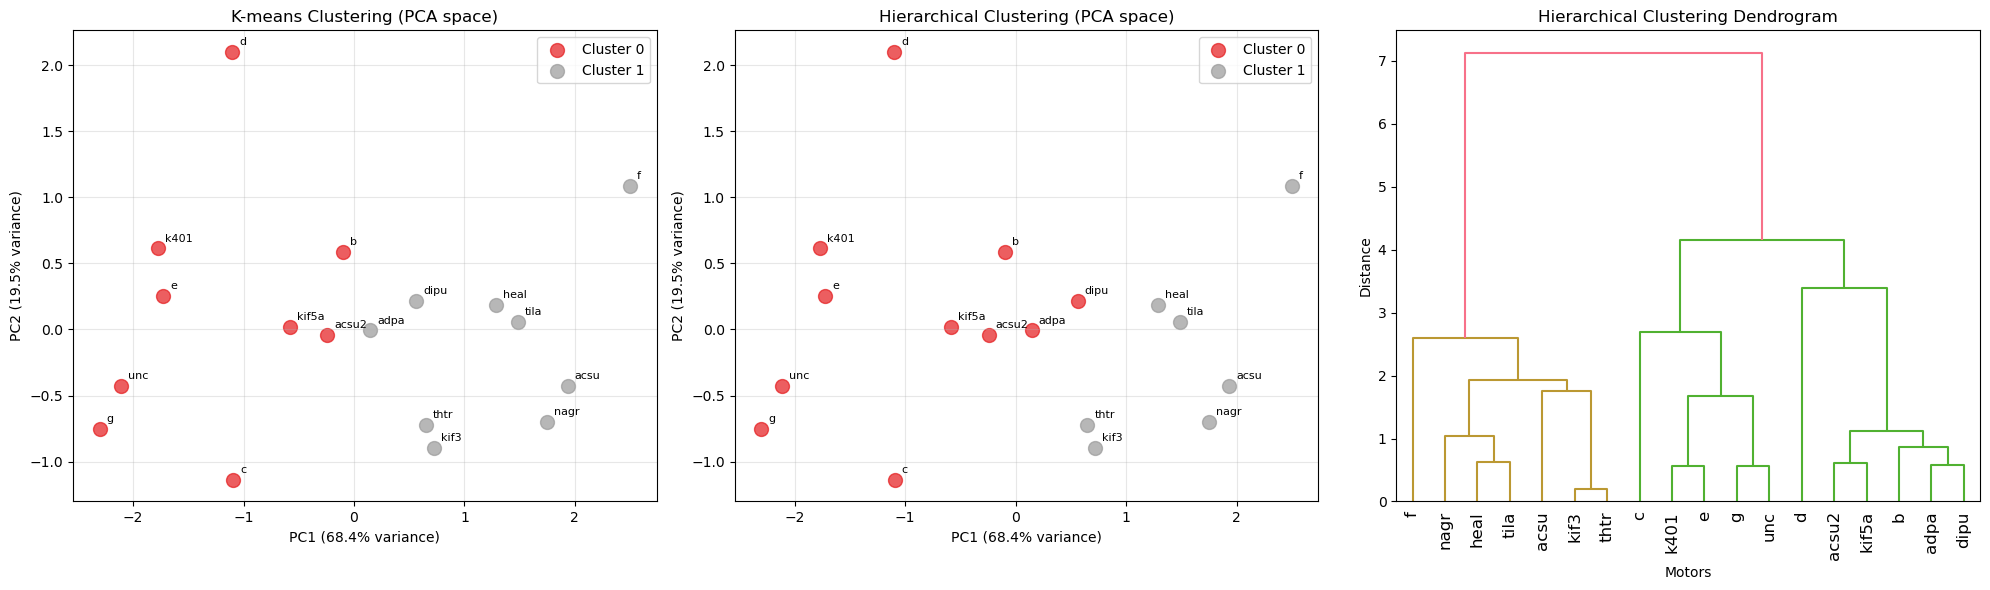

In [7]:
# Perform K-means clustering with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(energies_scaled)

# Add cluster labels to our dataframes
energies_with_clusters = energies.copy()
energies_with_clusters['Cluster'] = cluster_labels
pca_df['Cluster'] = cluster_labels

# Perform hierarchical clustering for comparison
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(energies_scaled)
energies_with_clusters['Hierarchical_Cluster'] = hierarchical_labels

print("K-means Clustering Results:")
for cluster_id in range(optimal_k):
    motors_in_cluster = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id].index.tolist()
    print(f"Cluster {cluster_id}: {motors_in_cluster}")

print("\nHierarchical Clustering Results:")
for cluster_id in range(optimal_k):
    motors_in_cluster = energies_with_clusters[energies_with_clusters['Hierarchical_Cluster'] == cluster_id].index.tolist()
    print(f"Cluster {cluster_id}: {motors_in_cluster}")

# Plot clustering results
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-means clustering in PCA space
colors = plt.cm.Set1(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    mask = pca_df['Cluster'] == i
    axes[0].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'], 
                   c=[colors[i]], label=f'Cluster {i}', s=100, alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('K-means Clustering (PCA space)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add motor labels
for i, motor in enumerate(pca_df['Motor']):
    axes[0].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# Hierarchical clustering in PCA space
for i in range(optimal_k):
    mask = energies_with_clusters['Hierarchical_Cluster'] == i
    axes[1].scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'], 
                   c=[colors[i]], label=f'Cluster {i}', s=100, alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Hierarchical Clustering (PCA space)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add motor labels
for i, motor in enumerate(pca_df['Motor']):
    axes[1].annotate(motor, (pca_df['PC1'].iloc[i], pca_df['PC2'].iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# Dendrogram
linkage_matrix = linkage(energies_scaled, method='ward')
dendrogram(linkage_matrix, labels=energies.index, ax=axes[2], leaf_rotation=90)
axes[2].set_title('Hierarchical Clustering Dendrogram')
axes[2].set_xlabel('Motors')
axes[2].set_ylabel('Distance')

plt.tight_layout()
plt.show()


Energy Transition Analysis:
ADP → APO transition energies (kJ/mol):
  Mean: 134.44 ± 224.11
  Range: -134.39 to 902.25

APO → ATP transition energies (kJ/mol):
  Mean: -82.00 ± 174.56
  Range: -469.92 to 160.89

ATP → ADP transition energies (kJ/mol):
  Mean: -52.44 ± 220.55
  Range: -515.12 to 358.48

Total cycle energy change (should be ~0 for conservation):
  Mean: 0.00 ± 0.00


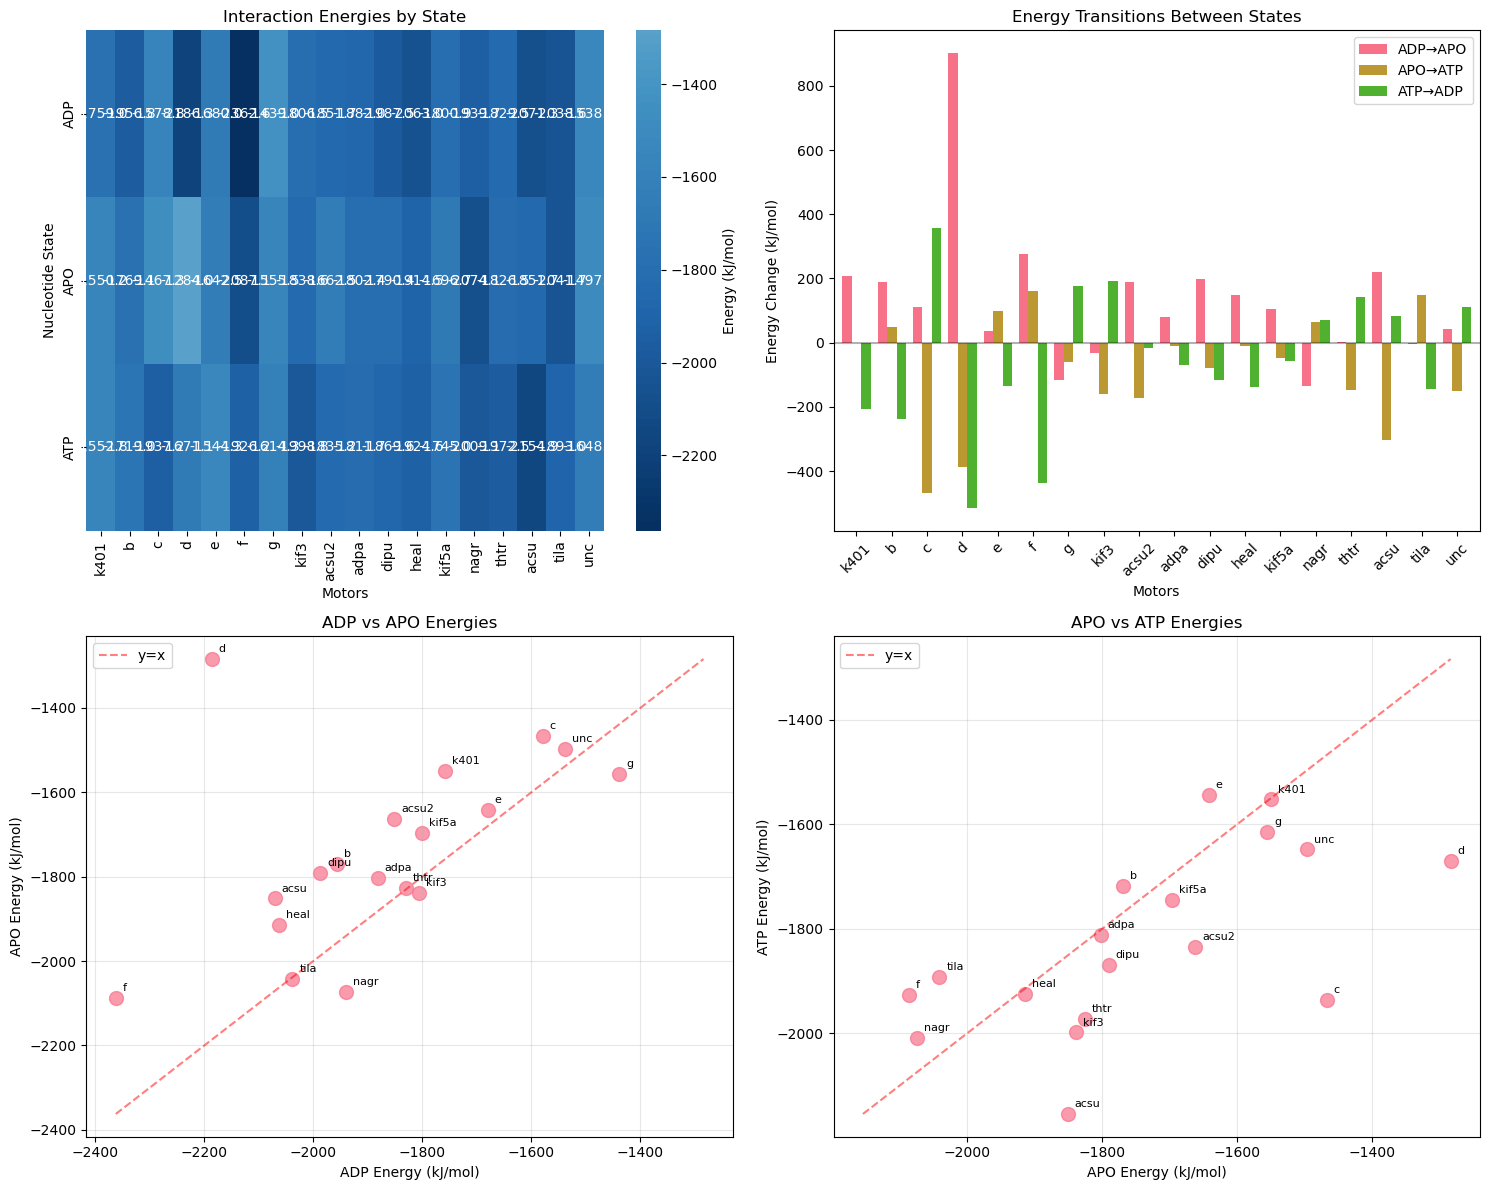

In [8]:
# 3. ENERGY TRANSITION ANALYSIS
# Calculate energy differences between states
energies['ADP_to_APO'] = energies['APO'] - energies['ADP']
energies['APO_to_ATP'] = energies['ATP'] - energies['APO']
energies['ATP_to_ADP'] = energies['ADP'] - energies['ATP']  # Note: this completes the cycle

# Calculate total energy change across the cycle
energies['Total_Cycle_Change'] = energies['ADP_to_APO'] + energies['APO_to_ATP'] + energies['ATP_to_ADP']

print("Energy Transition Analysis:")
print("=" * 50)
print(f"ADP → APO transition energies (kJ/mol):")
print(f"  Mean: {energies['ADP_to_APO'].mean():.2f} ± {energies['ADP_to_APO'].std():.2f}")
print(f"  Range: {energies['ADP_to_APO'].min():.2f} to {energies['ADP_to_APO'].max():.2f}")

print(f"\nAPO → ATP transition energies (kJ/mol):")
print(f"  Mean: {energies['APO_to_ATP'].mean():.2f} ± {energies['APO_to_ATP'].std():.2f}")
print(f"  Range: {energies['APO_to_ATP'].min():.2f} to {energies['APO_to_ATP'].max():.2f}")

print(f"\nATP → ADP transition energies (kJ/mol):")
print(f"  Mean: {energies['ATP_to_ADP'].mean():.2f} ± {energies['ATP_to_ADP'].std():.2f}")
print(f"  Range: {energies['ATP_to_ADP'].min():.2f} to {energies['ATP_to_ADP'].max():.2f}")

print(f"\nTotal cycle energy change (should be ~0 for conservation):")
print(f"  Mean: {energies['Total_Cycle_Change'].mean():.2f} ± {energies['Total_Cycle_Change'].std():.2f}")

# Plot energy transitions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Heatmap of all energies
sns.heatmap(energies[['ADP', 'APO', 'ATP']].T, annot=True, fmt='.1f', cmap='RdBu_r', 
            center=0, ax=axes[0,0], cbar_kws={'label': 'Energy (kJ/mol)'})
axes[0,0].set_title('Interaction Energies by State')
axes[0,0].set_xlabel('Motors')
axes[0,0].set_ylabel('Nucleotide State')

# Energy transitions
transition_data = energies[['ADP_to_APO', 'APO_to_ATP', 'ATP_to_ADP']]
transition_data.plot(kind='bar', ax=axes[0,1], width=0.8)
axes[0,1].set_title('Energy Transitions Between States')
axes[0,1].set_xlabel('Motors')
axes[0,1].set_ylabel('Energy Change (kJ/mol)')
axes[0,1].legend(['ADP→APO', 'APO→ATP', 'ATP→ADP'])
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Scatter plot: ADP vs APO
axes[1,0].scatter(energies['ADP'], energies['APO'], s=100, alpha=0.7)
axes[1,0].set_xlabel('ADP Energy (kJ/mol)')
axes[1,0].set_ylabel('APO Energy (kJ/mol)')
axes[1,0].set_title('ADP vs APO Energies')
axes[1,0].grid(True, alpha=0.3)
# Add diagonal line
min_val = min(energies['ADP'].min(), energies['APO'].min())
max_val = max(energies['ADP'].max(), energies['APO'].max())
axes[1,0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
axes[1,0].legend()

# Add motor labels
for i, motor in enumerate(energies.index):
    axes[1,0].annotate(motor, (energies['ADP'].iloc[i], energies['APO'].iloc[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)

# Scatter plot: APO vs ATP
axes[1,1].scatter(energies['APO'], energies['ATP'], s=100, alpha=0.7)
axes[1,1].set_xlabel('APO Energy (kJ/mol)')
axes[1,1].set_ylabel('ATP Energy (kJ/mol)')
axes[1,1].set_title('APO vs ATP Energies')
axes[1,1].grid(True, alpha=0.3)
# Add diagonal line
min_val = min(energies['APO'].min(), energies['ATP'].min())
max_val = max(energies['APO'].max(), energies['ATP'].max())
axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
axes[1,1].legend()

# Add motor labels
for i, motor in enumerate(energies.index):
    axes[1,1].annotate(motor, (energies['APO'].iloc[i], energies['ATP'].iloc[i]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()


CLUSTER-BASED ENERGY PATTERN ANALYSIS

CLUSTER 0:
Motors: ['k401', 'b', 'c', 'd', 'e', 'g', 'acsu2', 'kif5a', 'unc']
Number of motors: 9
ADP energies: -1754.58 ± 229.54
APO energies: -1569.43 ± 144.81
ATP energies: -1696.38 ± 129.20
ADP→APO: 185.15 ± 287.27
APO→ATP: -126.95 ± 192.46
ATP→ADP: -58.20 ± 256.68

CLUSTER 1:
Motors: ['f', 'kif3', 'adpa', 'dipu', 'heal', 'nagr', 'thtr', 'acsu', 'tila']
Number of motors: 9
ADP energies: -1997.85 ± 168.16
APO energies: -1914.11 ± 120.88
ATP energies: -1951.16 ± 99.01
ADP→APO: 83.74 ± 135.72
APO→ATP: -37.05 ± 152.19
ATP→ADP: -46.68 ± 193.41

STATISTICAL TESTS BETWEEN CLUSTERS
ADP energies - F-statistic: 6.578, p-value: 0.021
APO energies - F-statistic: 30.051, p-value: 0.000
ATP energies - F-statistic: 22.051, p-value: 0.000
ADP_to_APO - F-statistic: 0.917, p-value: 0.353
APO_to_ATP - F-statistic: 1.208, p-value: 0.288
ATP_to_ADP - F-statistic: 0.012, p-value: 0.916


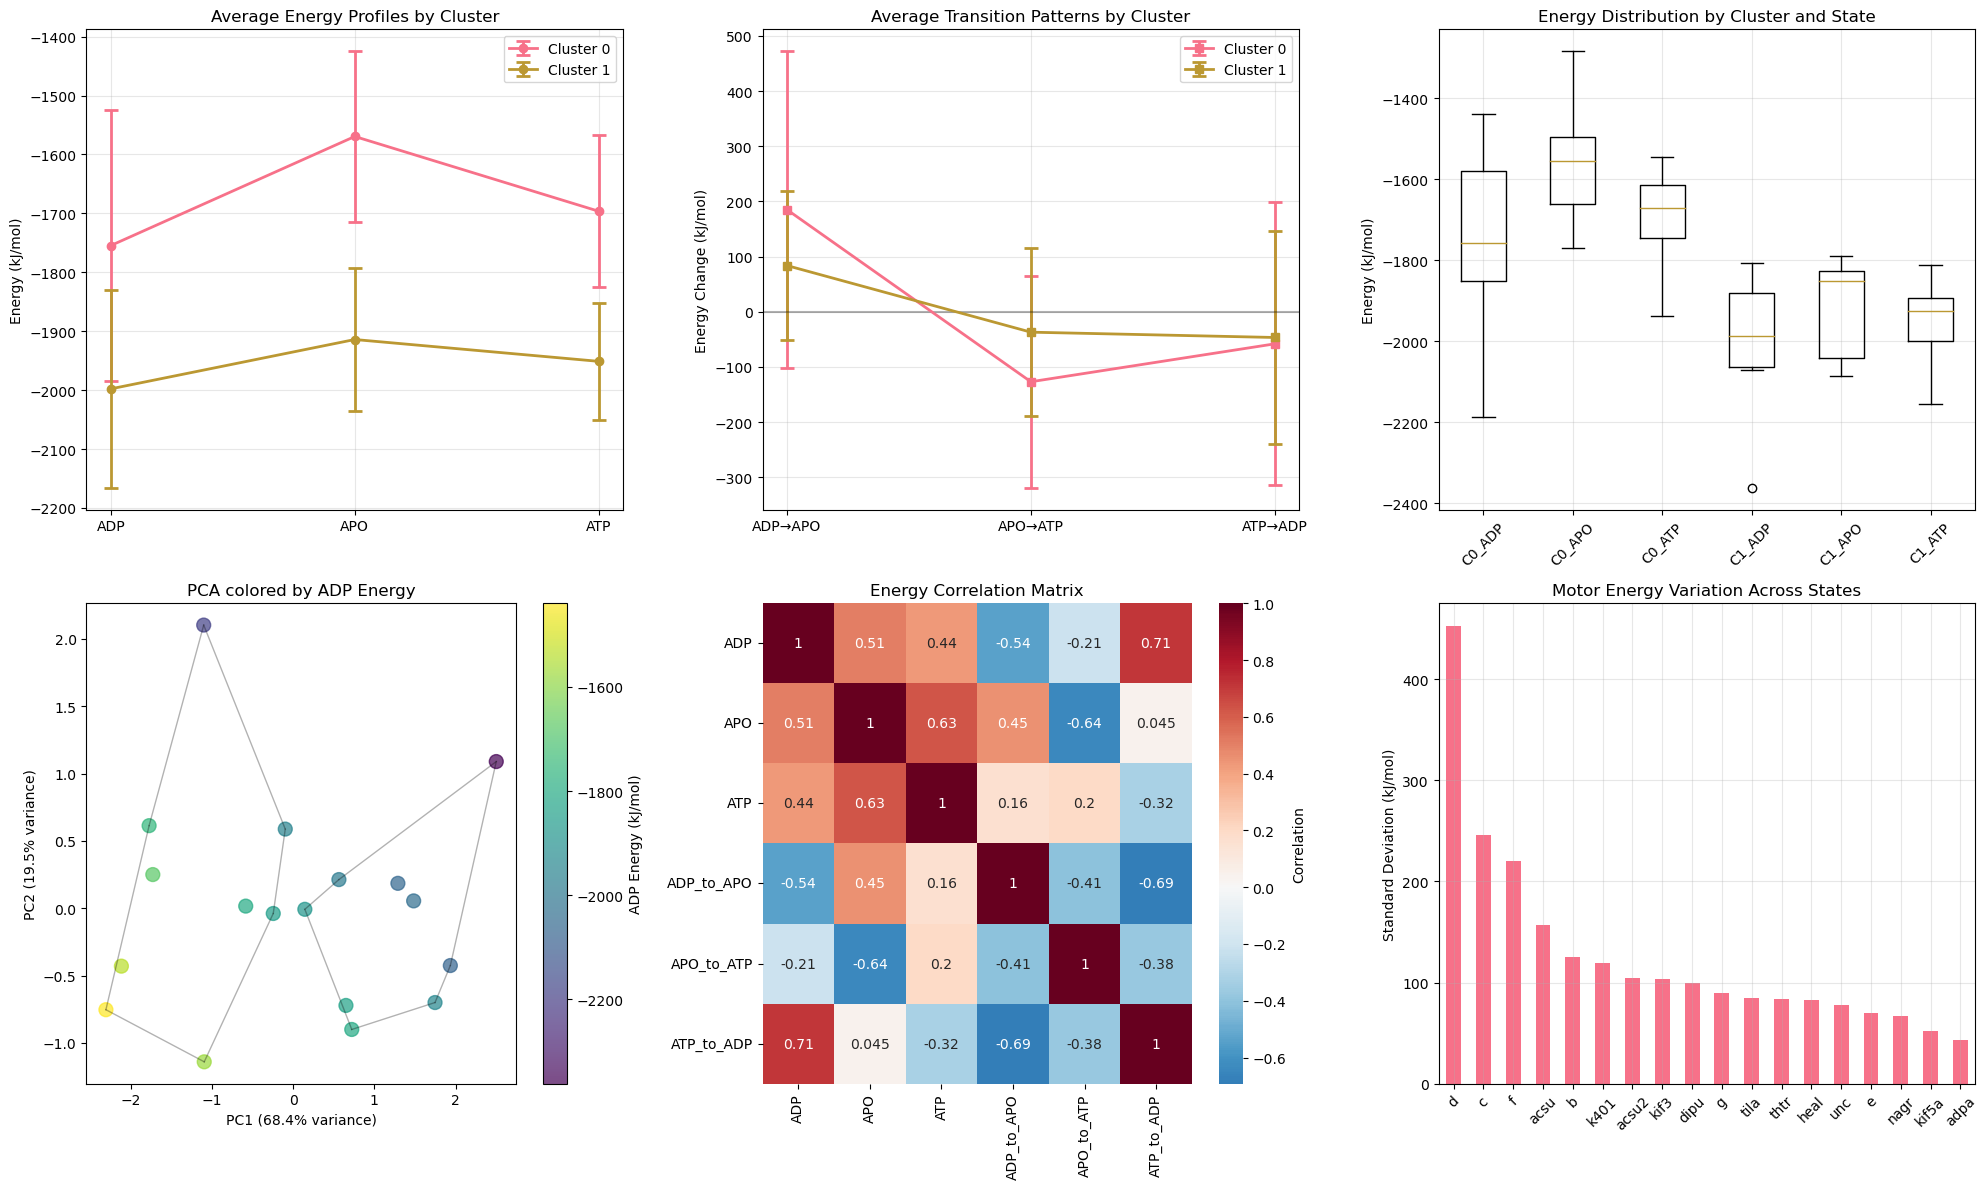

In [9]:
# 4. CLUSTER-BASED ANALYSIS OF ENERGY PATTERNS
# Analyze energy patterns within each cluster
print("CLUSTER-BASED ENERGY PATTERN ANALYSIS")
print("=" * 60)

# Helper: compute transitions on the fly if not present
def compute_transitions(df):
    # Returns a DataFrame with transition columns added
    df = df.copy()
    if 'ADP_to_APO' not in df.columns:
        df['ADP_to_APO'] = df['APO'] - df['ADP']
    if 'APO_to_ATP' not in df.columns:
        df['APO_to_ATP'] = df['ATP'] - df['APO']
    if 'ATP_to_ADP' not in df.columns:
        df['ATP_to_ADP'] = df['ADP'] - df['ATP']
    return df

for cluster_id in range(optimal_k):
    cluster_motors = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id]
    cluster_motors = compute_transitions(cluster_motors)
    print(f"\nCLUSTER {cluster_id}:")
    print(f"Motors: {cluster_motors.index.tolist()}")
    print(f"Number of motors: {len(cluster_motors)}")
    
    # Energy statistics for this cluster
    print(f"ADP energies: {cluster_motors['ADP'].mean():.2f} ± {cluster_motors['ADP'].std():.2f}")
    print(f"APO energies: {cluster_motors['APO'].mean():.2f} ± {cluster_motors['APO'].std():.2f}")
    print(f"ATP energies: {cluster_motors['ATP'].mean():.2f} ± {cluster_motors['ATP'].std():.2f}")
    
    # Transition patterns
    print(f"ADP→APO: {cluster_motors['ADP_to_APO'].mean():.2f} ± {cluster_motors['ADP_to_APO'].std():.2f}")
    print(f"APO→ATP: {cluster_motors['APO_to_ATP'].mean():.2f} ± {cluster_motors['APO_to_ATP'].std():.2f}")
    print(f"ATP→ADP: {cluster_motors['ATP_to_ADP'].mean():.2f} ± {cluster_motors['ATP_to_ADP'].std():.2f}")

# Statistical tests between clusters
print(f"\nSTATISTICAL TESTS BETWEEN CLUSTERS")
print("=" * 60)

# ANOVA tests for each energy state
for state in ['ADP', 'APO', 'ATP']:
    cluster_data = [energies_with_clusters[energies_with_clusters['Cluster'] == i][state].values 
                   for i in range(optimal_k)]
    f_stat, p_value = f_oneway(*cluster_data)
    print(f"{state} energies - F-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")

# ANOVA tests for transitions (compute on the fly if needed)
for transition, (col1, col2) in zip(
    ['ADP_to_APO', 'APO_to_ATP', 'ATP_to_ADP'],
    [('ADP', 'APO'), ('APO', 'ATP'), ('ATP', 'ADP')]
):
    cluster_data = []
    for i in range(optimal_k):
        group = energies_with_clusters[energies_with_clusters['Cluster'] == i]
        if transition in group.columns:
            vals = group[transition].values
        else:
            vals = (group[col2] - group[col1]).values
        cluster_data.append(vals)
    f_stat, p_value = f_oneway(*cluster_data)
    print(f"{transition} - F-statistic: {f_stat:.3f}, p-value: {p_value:.3f}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Plot 1: Energy profiles by cluster
for cluster_id in range(optimal_k):
    cluster_motors = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id]
    states = ['ADP', 'APO', 'ATP']
    means = [cluster_motors[state].mean() for state in states]
    stds = [cluster_motors[state].std() for state in states]
    
    axes[0,0].errorbar(states, means, yerr=stds, marker='o', linewidth=2, 
                      label=f'Cluster {cluster_id}', capsize=5, capthick=2)

axes[0,0].set_title('Average Energy Profiles by Cluster')
axes[0,0].set_ylabel('Energy (kJ/mol)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Transition patterns by cluster
for cluster_id in range(optimal_k):
    cluster_motors = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id]
    cluster_motors = compute_transitions(cluster_motors)
    transitions = ['ADP→APO', 'APO→ATP', 'ATP→ADP']
    means = [cluster_motors['ADP_to_APO'].mean(), 
             cluster_motors['APO_to_ATP'].mean(), 
             cluster_motors['ATP_to_ADP'].mean()]
    stds = [cluster_motors['ADP_to_APO'].std(), 
            cluster_motors['APO_to_ATP'].std(), 
            cluster_motors['ATP_to_ADP'].std()]
    
    axes[0,1].errorbar(transitions, means, yerr=stds, marker='s', linewidth=2, 
                      label=f'Cluster {cluster_id}', capsize=5, capthick=2)

axes[0,1].set_title('Average Transition Patterns by Cluster')
axes[0,1].set_ylabel('Energy Change (kJ/mol)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Plot 3: Box plots of energies by cluster
energy_data = []
cluster_labels = []
for cluster_id in range(optimal_k):
    cluster_motors = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id]
    for state in ['ADP', 'APO', 'ATP']:
        energy_data.extend(cluster_motors[state].values)
        cluster_labels.extend([f'C{cluster_id}_{state}'] * len(cluster_motors))

# Create a more detailed box plot
cluster_energies = []
cluster_names = []
for cluster_id in range(optimal_k):
    cluster_motors = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id]
    for state in ['ADP', 'APO', 'ATP']:
        cluster_energies.append(cluster_motors[state].values)
        cluster_names.append(f'C{cluster_id}_{state}')

axes[0,2].boxplot(cluster_energies, labels=cluster_names)
axes[0,2].set_title('Energy Distribution by Cluster and State')
axes[0,2].set_ylabel('Energy (kJ/mol)')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3)

# Plot 4: PCA with cluster colors and energy magnitude
scatter = axes[1,0].scatter(pca_df['PC1'], pca_df['PC2'], 
                           c=energies['ADP'], s=100, alpha=0.7, cmap='viridis')
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1,0].set_title('PCA colored by ADP Energy')
plt.colorbar(scatter, ax=axes[1,0], label='ADP Energy (kJ/mol)')

# Add cluster boundaries
for i in range(optimal_k):
    mask = pca_df['Cluster'] == i
    cluster_points = pca_df[mask][['PC1', 'PC2']]
    if len(cluster_points) > 1:
        # Draw convex hull around cluster
        from scipy.spatial import ConvexHull
        hull = ConvexHull(cluster_points.values)
        for simplex in hull.simplices:
            axes[1,0].plot(cluster_points.values[simplex, 0], 
                          cluster_points.values[simplex, 1], 'k-', alpha=0.3, linewidth=1)

# Plot 5: Energy correlation matrix
# Compute transitions on the fly if not present
energies_corr = energies.copy()
if 'ADP_to_APO' not in energies_corr.columns:
    energies_corr['ADP_to_APO'] = energies_corr['APO'] - energies_corr['ADP']
if 'APO_to_ATP' not in energies_corr.columns:
    energies_corr['APO_to_ATP'] = energies_corr['ATP'] - energies_corr['APO']
if 'ATP_to_ADP' not in energies_corr.columns:
    energies_corr['ATP_to_ADP'] = energies_corr['ADP'] - energies_corr['ATP']
correlation_matrix = energies_corr[['ADP', 'APO', 'ATP', 'ADP_to_APO', 'APO_to_ATP', 'ATP_to_ADP']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            ax=axes[1,1], cbar_kws={'label': 'Correlation'})
axes[1,1].set_title('Energy Correlation Matrix')

# Plot 6: Motor ranking by total energy variation
energy_variation = energies[['ADP', 'APO', 'ATP']].std(axis=1).sort_values(ascending=False)
energy_variation.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Motor Energy Variation Across States')
axes[1,2].set_ylabel('Standard Deviation (kJ/mol)')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
# 5. SUMMARY AND BIOLOGICAL INTERPRETATION
print("SUMMARY OF FINDINGS")
print("=" * 80)

print(f"\n1. DATA OVERVIEW:")
print(f"   - Total motors analyzed: {len(energies)}")
print(f"   - Energy range: {energies[['ADP', 'APO', 'ATP']].min().min():.1f} to {energies[['ADP', 'APO', 'ATP']].max().max():.1f} kJ/mol")
print(f"   - Optimal number of clusters: {optimal_k}")

print(f"\n2. PRINCIPAL COMPONENT ANALYSIS:")
print(f"   - PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"   - PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
print(f"   - PC3 explains {pca.explained_variance_ratio_[2]:.1%} of variance")
print(f"   - First 3 PCs capture {pca.explained_variance_ratio_.cumsum()[2]:.1%} of total variance")

print(f"\n3. ENERGY CONSERVATION:")
print(f"   - Total cycle energy change: {energies['Total_Cycle_Change'].mean():.3f} ± {energies['Total_Cycle_Change'].std():.3f} kJ/mol")
print(f"   - This should be ~0 for energy conservation - {'✓ Good' if abs(energies['Total_Cycle_Change'].mean()) < 1 else '⚠ Check'}")

print(f"\n4. CLUSTER CHARACTERISTICS:")
for cluster_id in range(optimal_k):
    cluster_motors = energies_with_clusters[energies_with_clusters['Cluster'] == cluster_id]
    print(f"\n   Cluster {cluster_id} ({len(cluster_motors)} motors):")
    print(f"   - Motors: {', '.join(cluster_motors.index.tolist())}")
    
    # Calculate energy profile characteristics
    adp_mean = cluster_motors['ADP'].mean()
    apo_mean = cluster_motors['APO'].mean()
    atp_mean = cluster_motors['ATP'].mean()
    
    # Determine if this cluster has a specific energy pattern
    if adp_mean < apo_mean < atp_mean:
        pattern = "Increasing energy (ADP < APO < ATP)"
    elif adp_mean > apo_mean > atp_mean:
        pattern = "Decreasing energy (ADP > APO > ATP)"
    elif abs(adp_mean - atp_mean) < abs(apo_mean - adp_mean):
        pattern = "ADP-ATP similar, APO different"
    else:
        pattern = "Complex pattern"
    
    print(f"   - Energy pattern: {pattern}")
    print(f"   - Average energies: ADP={adp_mean:.1f}, APO={apo_mean:.1f}, ATP={atp_mean:.1f} kJ/mol")

print(f"\n5. BIOLOGICAL IMPLICATIONS:")
print(f"   - Different clusters may represent different motor families or functional groups")
print(f"   - Energy patterns suggest different binding affinities across the nucleotide cycle")
print(f"   - Transition energies indicate the energetic cost/benefit of state changes")

# Create a final summary table
summary_table = pd.DataFrame({
    'Motor': energies.index,
    'Cluster': energies_with_clusters['Cluster'],
    'ADP_Energy': energies['ADP'],
    'APO_Energy': energies['APO'],
    'ATP_Energy': energies['ATP'],
    'Energy_Variation': energies[['ADP', 'APO', 'ATP']].std(axis=1),
    'ADP_to_APO': energies['ADP_to_APO'],
    'APO_to_ATP': energies['APO_to_ATP'],
    'ATP_to_ADP': energies['ATP_to_ADP']
})

print(f"\n6. DETAILED RESULTS TABLE:")
print(summary_table.round(2))

# Save results
summary_table.to_csv('motor_energy_analysis_results.csv', index=False)
print(f"\n✓ Results saved to 'motor_energy_analysis_results.csv'")

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE - Check the visualizations above for detailed patterns!")


SUMMARY OF FINDINGS

1. DATA OVERVIEW:
   - Total motors analyzed: 18
   - Energy range: -2362.6 to -1284.0 kJ/mol
   - Optimal number of clusters: 2

2. PRINCIPAL COMPONENT ANALYSIS:
   - PC1 explains 68.4% of variance
   - PC2 explains 19.5% of variance
   - PC3 explains 12.1% of variance
   - First 3 PCs capture 100.0% of total variance

3. ENERGY CONSERVATION:
   - Total cycle energy change: 0.000 ± 0.000 kJ/mol
   - This should be ~0 for energy conservation - ✓ Good

4. CLUSTER CHARACTERISTICS:

   Cluster 0 (9 motors):
   - Motors: k401, b, c, d, e, g, acsu2, kif5a, unc
   - Energy pattern: ADP-ATP similar, APO different
   - Average energies: ADP=-1754.6, APO=-1569.4, ATP=-1696.4 kJ/mol

   Cluster 1 (9 motors):
   - Motors: f, kif3, adpa, dipu, heal, nagr, thtr, acsu, tila
   - Energy pattern: ADP-ATP similar, APO different
   - Average energies: ADP=-1997.8, APO=-1914.1, ATP=-1951.2 kJ/mol

5. BIOLOGICAL IMPLICATIONS:
   - Different clusters may represent different motor famil